<a href="https://colab.research.google.com/github/ProfessorPatrickSlatraigh/cis9557__baseline/blob/main/CIS9557_MovingAverages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Moving Average Stock Price Estimator
  CIS 9557 — Business Analytics

Enter the stock ticker symbol (e.g., AAPL): AAPL
Enter the estimation start date (YYYY-MM-DD): 2026-02-09

Ticker:            AAPL
Estimation start:  2026-02-09

  Received 378 trading days of data.
  Date range: 2024-08-08 to 2026-02-10

Moving averages computed:
  MA_30 available from: 2024-09-19
  MA_90 available from: 2024-12-13

Anchor trading day (last day of historical data): 2026-02-09
  Closing price on anchor date:  $274.62
  MA_30 on anchor date:          $262.75
  MA_90 on anchor date:          $266.10

52-Week Trend Line (OLS Linear Regression):
  Period:       2025-02-07 to 2026-02-09 (252 trading days)
  Slope:        $+0.2910 per trading day
  Annualized:   $+73.33 per year
  Intercept:    $197.98
  R²:           0.5710
  r (Pearson):  +0.7557
  p-value:      7.57e-48
  Std Error:    $0.0160

Daily drift of MA_30 (over last 10 days): $-0.1582 per day

Generated 30-day forward estimates:
  First esti

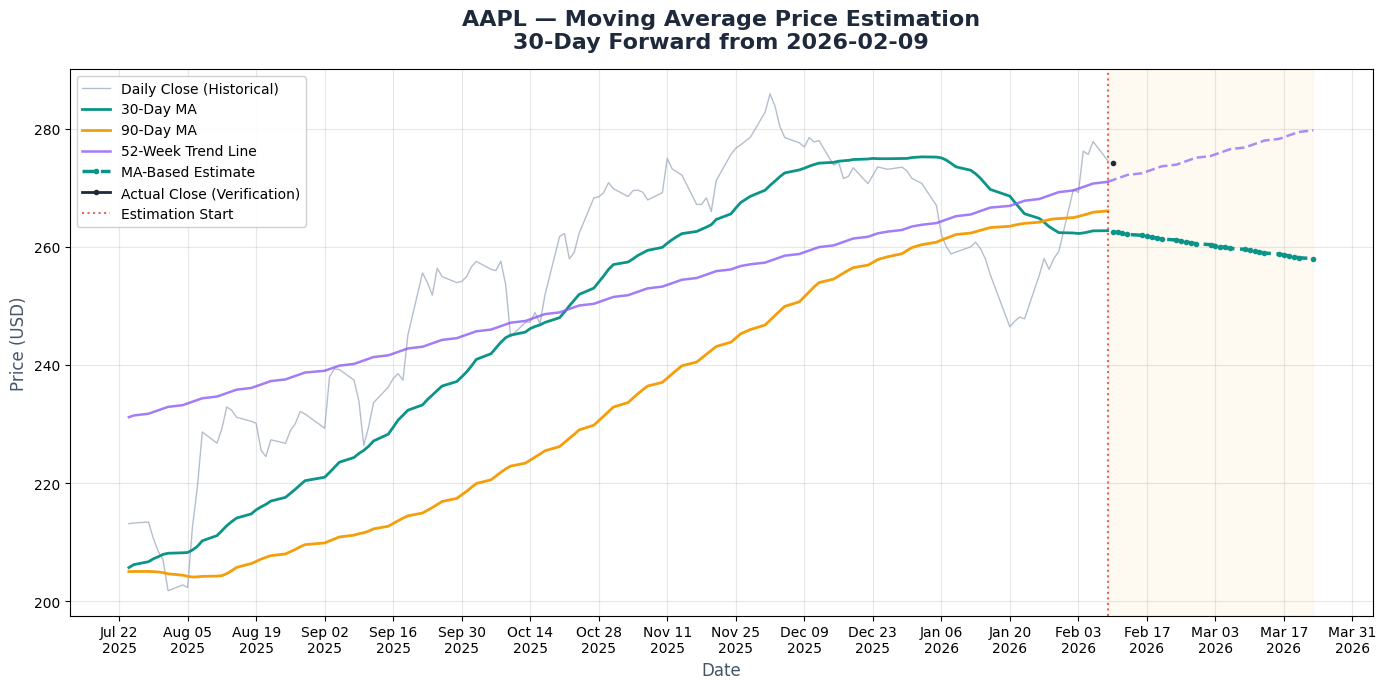

In [2]:
"""
Moving Average Stock Price Estimator
=====================================
CIS 9557 Business Analytics — Supplemental Module
Zicklin School of Business, Baruch College, CUNY

This script demonstrates how to use 30-day and 90-day moving averages
to estimate a stock's closing price 30 trading days into the future.

It also computes a 52-week linear trend line (OLS regression) based on
the most recent 252 trading days, extends that trend through the 30-day
estimation period, and reports the regression statistics (slope,
intercept, R², p-value, standard error).  The trend line appears on the
chart alongside the moving averages and serves as a long-term
directional reference for interpreting the MA-based estimate.

Prerequisites (install once from your terminal or command prompt):
    pip install yfinance pandas matplotlib numpy scipy

How to run:
    python moving_average_estimator.py

The script will prompt you for:
    1. A ticker symbol (e.g., AAPL, MSFT, GOOG)
    2. A start date from which to begin the 30-day forward estimate
"""

# ---------------------------------------------------------------------------
# SECTION 1: Import the libraries we need
# ---------------------------------------------------------------------------
# 'yfinance' downloads historical stock data from Yahoo Finance.
# 'pandas' is the standard Python library for working with tabular data.
# 'numpy' provides numerical array operations and is used for regression.
# 'matplotlib' creates charts and plots.
# 'datetime' and 'timedelta' let us work with dates and date arithmetic.
# 'scipy.stats' provides the linregress function for OLS trend fitting.
# 'sys' provides access to system-level functions (we use it to exit on error).

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from scipy import stats
import sys


# ---------------------------------------------------------------------------
# SECTION 2: Collect user input
# ---------------------------------------------------------------------------
# We ask the user for two pieces of information:
#   - The ticker symbol identifies which stock to analyze.
#   - The estimation start date is the day from which we project 30 days
#     forward.  The script will use all available data BEFORE this date to
#     compute the moving averages, and then compare the 30-day projection
#     against actual closing prices (if they exist) after that date.

print("=" * 65)
print("  Moving Average Stock Price Estimator")
print("  CIS 9557 — Business Analytics")
print("=" * 65)
print()

# --- Ticker symbol ---
# The ticker is the short abbreviation used on stock exchanges.
# Examples: AAPL (Apple), MSFT (Microsoft), GOOG (Alphabet/Google),
#           AMZN (Amazon), TSLA (Tesla), JPM (JPMorgan Chase)

ticker_symbol = input("Enter the stock ticker symbol (e.g., AAPL): ").strip().upper()

if not ticker_symbol:
    print("Error: No ticker symbol provided. Exiting.")
    sys.exit(1)

# --- Estimation start date ---
# This is the last day of "known" data from which we project forward.
# Format: YYYY-MM-DD (four-digit year, two-digit month, two-digit day)
# Example: 2025-01-15 means January 15, 2025.

date_input = input("Enter the estimation start date (YYYY-MM-DD): ").strip()

try:
    estimation_start = datetime.strptime(date_input, "%Y-%m-%d")
except ValueError:
    print(f"Error: '{date_input}' is not a valid date in YYYY-MM-DD format. Exiting.")
    sys.exit(1)

print()
print(f"Ticker:            {ticker_symbol}")
print(f"Estimation start:  {estimation_start.strftime('%Y-%m-%d')}")
print()


# ---------------------------------------------------------------------------
# SECTION 3: Download historical price data from Yahoo Finance
# ---------------------------------------------------------------------------
# We download enough data to cover the 90-day moving average PLUS a generous
# buffer.  Specifically, we request data starting 200 trading days (~10
# calendar months) before the estimation start date.  We also request data
# up through today so that we can perform variance analysis on dates where
# both an estimate and an actual closing price exist.
#
# The yfinance library returns a pandas DataFrame — think of it as a
# spreadsheet in memory.  Each row is one trading day, and the columns
# include Open, High, Low, Close, and Volume.

download_start = estimation_start - timedelta(days=550)  # ~1.5 years before (covers 52-week trend)
download_end = datetime.today() + timedelta(days=1)       # through today

print(f"Downloading {ticker_symbol} data from {download_start.strftime('%Y-%m-%d')} "
      f"to {download_end.strftime('%Y-%m-%d')}...")

# The 'auto_adjust=True' parameter means the Close column already reflects
# stock splits and dividends — this is the standard "adjusted close."
try:
    ticker = yf.Ticker(ticker_symbol)
    df = ticker.history(start=download_start.strftime("%Y-%m-%d"),
                        end=download_end.strftime("%Y-%m-%d"),
                        auto_adjust=True)
except Exception as e:
    print(f"Error downloading data: {e}")
    sys.exit(1)

# Check that we received data
if df.empty:
    print(f"Error: No data returned for '{ticker_symbol}'. "
          "Verify the ticker symbol is correct and try again.")
    sys.exit(1)

# The DataFrame index is a DatetimeIndex — each row's label is its date.
# We ensure the index is timezone-naive for cleaner date comparisons.
df.index = df.index.tz_localize(None)

print(f"  Received {len(df)} trading days of data.")
print(f"  Date range: {df.index[0].strftime('%Y-%m-%d')} to "
      f"{df.index[-1].strftime('%Y-%m-%d')}")
print()


# ---------------------------------------------------------------------------
# SECTION 4: Compute the 30-day and 90-day moving averages
# ---------------------------------------------------------------------------
# The pandas .rolling(window=N).mean() method does exactly what we described
# in the slides:
#   1. For each row, look back N rows (the "window").
#   2. Compute the arithmetic mean of the Close prices in that window.
#   3. Store the result in a new column.
#
# The first N-1 rows will contain NaN (Not a Number) because there are not
# yet enough data points to fill the window.

df["MA_30"] = df["Close"].rolling(window=30).mean()
df["MA_90"] = df["Close"].rolling(window=90).mean()

print("Moving averages computed:")
print(f"  MA_30 available from: {df['MA_30'].dropna().index[0].strftime('%Y-%m-%d')}")
print(f"  MA_90 available from: {df['MA_90'].dropna().index[0].strftime('%Y-%m-%d')}")
print()


# ---------------------------------------------------------------------------
# SECTION 4B: Split data into "historical" and "actual future" segments
# ---------------------------------------------------------------------------
# Historical data: everything up to and including the estimation start date.
#   This is the data we USE to build our estimate.
# Actual future data: everything AFTER the estimation start date.
#   This is data that we treat as "unknown" for estimation purposes, but
#   that we can use afterward to evaluate how good the estimate was.

# Find the last trading day on or before the estimation start date.
# (The user might enter a weekend or holiday, so we need the nearest
# trading day that is <= the requested date.)
historical = df[df.index <= estimation_start]

if historical.empty:
    print("Error: No historical data available before the estimation start date.")
    sys.exit(1)

anchor_date = historical.index[-1]  # The actual last trading day we use
print(f"Anchor trading day (last day of historical data): "
      f"{anchor_date.strftime('%Y-%m-%d')}")

# Verify that we have a valid MA_30 value on the anchor date
anchor_ma30 = historical["MA_30"].iloc[-1]
anchor_ma90 = historical["MA_90"].iloc[-1]

if pd.isna(anchor_ma30):
    print("Error: Not enough data to compute a 30-day moving average on the "
          "anchor date. Try an earlier start date or a different ticker.")
    sys.exit(1)

print(f"  Closing price on anchor date:  ${historical['Close'].iloc[-1]:.2f}")
print(f"  MA_30 on anchor date:          ${anchor_ma30:.2f}")
if not pd.isna(anchor_ma90):
    print(f"  MA_90 on anchor date:          ${anchor_ma90:.2f}")
else:
    print(f"  MA_90 on anchor date:          (insufficient data)")
print()


# ---------------------------------------------------------------------------
# SECTION 4C: Compute the 52-week linear trend line
# ---------------------------------------------------------------------------
# A linear trend line fitted to the most recent 52 weeks (~252 trading days)
# of daily closing prices provides a long-term directional reference.  We use
# ordinary least squares (OLS) regression via scipy.stats.linregress, which
# returns the slope, intercept, correlation coefficient (r), two-sided
# p-value for the null hypothesis that the slope is zero, and the standard
# error of the slope estimate.
#
# The independent variable is a sequential day index (0, 1, 2, ...) rather
# than raw dates, because linregress requires numeric inputs.  We record the
# mapping between day indices and calendar dates so the trend line can be
# extended into the forecast period.

TREND_WINDOW = 252  # Approximate number of trading days in 52 weeks

# Select the most recent TREND_WINDOW trading days up to the estimation start
trend_data = historical["Close"].dropna().tail(TREND_WINDOW)

if len(trend_data) < 60:
    print("Warning: Fewer than 60 trading days available for trend line.")
    print("         Trend statistics may be unreliable.")
    print()

# Create a numeric day index: 0, 1, 2, ..., N-1
trend_x = np.arange(len(trend_data))
trend_y = trend_data.values

# Ordinary least squares linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(trend_x, trend_y)

r_squared = r_value ** 2
trend_n_days = len(trend_data)
trend_start_date = trend_data.index[0]
trend_end_date = trend_data.index[-1]

# Annualized slope: approximate dollar change per year (252 trading days)
annualized_slope = slope * 252

# Predicted values along the historical trend segment
trend_fitted = intercept + slope * trend_x

# The trend line's "day 0" corresponds to trend_start_date.  To extend the
# line into the forecast period, we compute how many trading-day indices
# beyond the last historical point each forecast date represents.  Since the
# forecast dates immediately follow the anchor date, the first forecast day
# has index = trend_n_days, the second = trend_n_days + 1, and so on.

print(f"52-Week Trend Line (OLS Linear Regression):")
print(f"  Period:       {trend_start_date.strftime('%Y-%m-%d')} to "
      f"{trend_end_date.strftime('%Y-%m-%d')} ({trend_n_days} trading days)")
print(f"  Slope:        ${slope:+.4f} per trading day")
print(f"  Annualized:   ${annualized_slope:+.2f} per year")
print(f"  Intercept:    ${intercept:.2f}")
print(f"  R²:           {r_squared:.4f}")
print(f"  r (Pearson):  {r_value:+.4f}")
print(f"  p-value:      {p_value:.2e}")
print(f"  Std Error:    ${std_err:.4f}")
print()


# ---------------------------------------------------------------------------
# SECTION 5: Compute the daily drift (slope of the MA_30)
# ---------------------------------------------------------------------------
# The "daily drift" measures how much the 30-day moving average has been
# changing per day in the recent past.  We compute it as:
#
#     daily_drift = (MA_30 ten days ago  →  MA_30 today) / 9
#
# This gives us the average daily change in the MA_30 over the last 10
# trading days.  We will use this slope to extrapolate forward.
#
# Why 10 days?  It is a reasonable compromise: long enough to smooth out
# day-to-day noise in the MA itself, short enough to reflect recent momentum.

DRIFT_WINDOW = 10  # Number of recent days used to estimate the slope

# Get the most recent DRIFT_WINDOW values of MA_30 from the historical data
recent_ma30 = historical["MA_30"].dropna().tail(DRIFT_WINDOW)

if len(recent_ma30) < DRIFT_WINDOW:
    print(f"Warning: Only {len(recent_ma30)} MA_30 values available for drift "
          f"calculation (requested {DRIFT_WINDOW}).  Results may be less reliable.")

# daily_drift = change over the window / number of intervals
daily_drift = (recent_ma30.iloc[-1] - recent_ma30.iloc[0]) / (len(recent_ma30) - 1)

print(f"Daily drift of MA_30 (over last {len(recent_ma30)} days): "
      f"${daily_drift:+.4f} per day")
print()


# ---------------------------------------------------------------------------
# SECTION 6: Generate the 30-day forward estimates
# ---------------------------------------------------------------------------
# We project the MA_30 forward by adding the daily drift incrementally:
#
#     Estimate(day k) = MA_30(anchor) + k * daily_drift
#
# where k = 1, 2, 3, ..., 30.
#
# To assign calendar dates to each projected day, we need to know which
# dates are actual trading days.  If we have actual future data in our
# download, we use those dates.  Otherwise, we approximate by skipping
# weekends (Saturday and Sunday).

FORECAST_DAYS = 30  # Number of trading days to project forward

# Collect actual trading dates after the anchor (if they exist)
actual_future = df[df.index > anchor_date]

# Build the list of forecast dates
if len(actual_future) >= FORECAST_DAYS:
    # We have enough actual trading dates — use them directly
    forecast_dates = actual_future.index[:FORECAST_DAYS].tolist()
else:
    # Start with whatever actual dates we have
    forecast_dates = actual_future.index.tolist()
    # Then approximate remaining dates by advancing from the last known date,
    # skipping weekends
    if len(forecast_dates) > 0:
        last_known = forecast_dates[-1]
    else:
        last_known = anchor_date
    while len(forecast_dates) < FORECAST_DAYS:
        last_known = last_known + timedelta(days=1)
        # Skip Saturday (5) and Sunday (6)
        if last_known.weekday() < 5:
            forecast_dates.append(last_known)

# Compute the estimated price for each forecast day
# k starts at 1 (the first day after the anchor)
estimates = []
for k, fdate in enumerate(forecast_dates, start=1):
    estimated_price = anchor_ma30 + k * daily_drift
    trend_day_index = trend_n_days - 1 + k
    trend_price = intercept + slope * trend_day_index
    estimates.append({
        "Date": fdate,
        "Day_k": k,
        "Estimated_Close": round(estimated_price, 2),
        "Trend_Estimate": round(trend_price, 2)
    })

# Store estimates in a DataFrame for easy display and analysis
est_df = pd.DataFrame(estimates)
est_df = est_df.set_index("Date")

print(f"Generated {FORECAST_DAYS}-day forward estimates:")
print(f"  First estimate:  {est_df.index[0].strftime('%Y-%m-%d')}  "
      f"${est_df['Estimated_Close'].iloc[0]:.2f}")
print(f"  Last estimate:   {est_df.index[-1].strftime('%Y-%m-%d')}  "
      f"${est_df['Estimated_Close'].iloc[-1]:.2f}")
print()


# ---------------------------------------------------------------------------
# SECTION 7: Variance analysis — compare estimates to actual prices
# ---------------------------------------------------------------------------
# If actual closing prices exist for any of the estimated dates, we can
# measure how well our simple model performed.  This is the same logic
# from Chapter 7: evaluate the model against observed outcomes.
#
# Metrics we compute:
#   - Error         = Actual - Estimated   (positive means we underestimated)
#   - Absolute Error = |Error|
#   - Percentage Error = Error / Actual * 100
#   - MAE  = Mean Absolute Error (average magnitude of errors)
#   - RMSE = Root Mean Squared Error (penalizes large errors more heavily)
#   - MPE  = Mean Percentage Error (directional bias indicator)
#   - MAPE = Mean Absolute Percentage Error (average % magnitude)

# Find dates that have BOTH an estimate and an actual closing price
overlapping_dates = est_df.index.intersection(df.index)

if len(overlapping_dates) > 0:
    print("=" * 65)
    print(f"  VARIANCE ANALYSIS: {len(overlapping_dates)} days with both "
          "estimate and actual data")
    print("=" * 65)
    print()

    # Build a comparison DataFrame
    comparison = pd.DataFrame({
        "Actual_Close": df.loc[overlapping_dates, "Close"],
        "Estimated_Close": est_df.loc[overlapping_dates, "Estimated_Close"]
    })

    # Compute error columns
    # Error: positive = underestimate (actual was higher), negative = overestimate
    comparison["Error"] = comparison["Actual_Close"] - comparison["Estimated_Close"]
    comparison["Abs_Error"] = comparison["Error"].abs()
    comparison["Pct_Error"] = (comparison["Error"] / comparison["Actual_Close"]) * 100

    # Display the day-by-day comparison table
    print("Day-by-Day Comparison:")
    print("-" * 65)
    print(f"{'Date':<12}  {'Actual':>10}  {'Estimated':>10}  "
          f"{'Error':>10}  {'% Error':>10}")
    print("-" * 65)

    for date, row in comparison.iterrows():
        print(f"{date.strftime('%Y-%m-%d'):<12}  "
              f"${row['Actual_Close']:>9.2f}  "
              f"${row['Estimated_Close']:>9.2f}  "
              f"${row['Error']:>+9.2f}  "
              f"{row['Pct_Error']:>+9.2f}%")

    print("-" * 65)
    print()

    # Compute summary statistics
    mae = comparison["Abs_Error"].mean()
    rmse = (comparison["Error"] ** 2).mean() ** 0.5
    mpe = comparison["Pct_Error"].mean()
    mape = comparison["Pct_Error"].abs().mean()
    max_error = comparison["Abs_Error"].max()
    max_error_date = comparison["Abs_Error"].idxmax()
    mean_error = comparison["Error"].mean()

    print("Summary Statistics:")
    print("-" * 65)
    print(f"  Mean Error (bias):                   ${mean_error:>+10.2f}")
    print(f"    (positive = model underestimates on average)")
    print(f"  Mean Absolute Error (MAE):           ${mae:>10.2f}")
    print(f"    (average magnitude of error, ignoring direction)")
    print(f"  Root Mean Squared Error (RMSE):      ${rmse:>10.2f}")
    print(f"    (penalizes large errors more than MAE)")
    print(f"  Mean Percentage Error (MPE):         {mpe:>+10.2f}%")
    print(f"    (directional bias as a percentage)")
    print(f"  Mean Absolute Percentage Error (MAPE): {mape:>8.2f}%")
    print(f"    (average error magnitude as a percentage)")
    print(f"  Maximum Single-Day Error:            ${max_error:>10.2f} "
          f"on {max_error_date.strftime('%Y-%m-%d')}")
    print("-" * 65)
    print()

    # --- Baseline comparison ---
    # Chapter 7 principle: always compare against a baseline.
    # Naive baseline: "the price will remain the same as the anchor day."
    anchor_close = historical["Close"].iloc[-1]
    baseline_errors = comparison["Actual_Close"] - anchor_close
    baseline_mae = baseline_errors.abs().mean()
    baseline_rmse = (baseline_errors ** 2).mean() ** 0.5

    print("Baseline Comparison (Naive: price stays at anchor close):")
    print("-" * 65)
    print(f"  Anchor closing price:                ${anchor_close:>10.2f}")
    print(f"  Baseline MAE:                        ${baseline_mae:>10.2f}")
    print(f"  Baseline RMSE:                       ${baseline_rmse:>10.2f}")
    print()
    if mae < baseline_mae:
        improvement = ((baseline_mae - mae) / baseline_mae) * 100
        print(f"  Result: The MA-based estimate outperforms the naive baseline.")
        print(f"          MAE improvement: {improvement:.1f}%")
    elif mae > baseline_mae:
        degradation = ((mae - baseline_mae) / baseline_mae) * 100
        print(f"  Result: The naive baseline outperforms the MA-based estimate.")
        print(f"          MAE degradation: {degradation:.1f}%")
    else:
        print(f"  Result: The MA-based estimate matches the naive baseline exactly.")
    print("-" * 65)
    print()

    # --- Trend line comparison ---
    # Compare the MA-based estimate and the 52-week trend line extrapolation
    # against actual prices over the overlapping forecast period.
    trend_forecast_values = []
    for k, fdate in enumerate(forecast_dates, start=1):
        trend_day_index = trend_n_days - 1 + k  # extend from last historical point
        trend_forecast_values.append(intercept + slope * trend_day_index)

    trend_est_series = pd.Series(trend_forecast_values, index=forecast_dates[:len(trend_forecast_values)])
    trend_overlap = trend_est_series.index.intersection(df.index)

    if len(trend_overlap) > 0:
        trend_comparison = pd.DataFrame({
            "Actual_Close": df.loc[trend_overlap, "Close"],
            "Trend_Estimate": trend_est_series.loc[trend_overlap]
        })
        trend_comparison["Error"] = trend_comparison["Actual_Close"] - trend_comparison["Trend_Estimate"]
        trend_mae = trend_comparison["Error"].abs().mean()
        trend_rmse = (trend_comparison["Error"] ** 2).mean() ** 0.5

        print("52-Week Trend Line — Forecast Accuracy:")
        print("-" * 65)
        print(f"  Trend Line MAE:                      ${trend_mae:>10.2f}")
        print(f"  Trend Line RMSE:                     ${trend_rmse:>10.2f}")
        print()
        print("  Three-Way Comparison (MAE):")
        print(f"    MA-Based Estimate:                 ${mae:>10.2f}")
        print(f"    52-Week Trend Line:                ${trend_mae:>10.2f}")
        print(f"    Naive Baseline (flat):             ${baseline_mae:>10.2f}")

        # Rank the three methods
        methods = [("MA-Based Estimate", mae),
                   ("52-Week Trend Line", trend_mae),
                   ("Naive Baseline", baseline_mae)]
        methods.sort(key=lambda m: m[1])
        print()
        print(f"  Rank:  1. {methods[0][0]:<28} (MAE ${methods[0][1]:.2f})")
        print(f"         2. {methods[1][0]:<28} (MAE ${methods[1][1]:.2f})")
        print(f"         3. {methods[2][0]:<28} (MAE ${methods[2][1]:.2f})")
        print("-" * 65)
        print()

else:
    print("No overlapping dates found between estimates and actual data.")
    print("  (The estimation start date may be too recent for actual data to exist.)")
    print("  Variance analysis is not available.")
    print()
    comparison = None


# ---------------------------------------------------------------------------
# SECTION 7B: 52-Week Trend Line — Descriptive Summary
# ---------------------------------------------------------------------------
# This section provides an interpretive description of the trend line,
# translating the regression statistics into plain-language observations.

print("=" * 65)
print("  52-WEEK TREND LINE ANALYSIS")
print("=" * 65)
print()

# Direction
if slope > 0:
    direction = "upward"
    direction_desc = "rising"
elif slope < 0:
    direction = "downward"
    direction_desc = "declining"
else:
    direction = "flat"
    direction_desc = "unchanged"

print(f"  Direction:  The 52-week trend is {direction}.")
print(f"    On average, {ticker_symbol} has been {direction_desc} by "
      f"${abs(slope):.4f} per trading day,")
print(f"    or approximately ${abs(annualized_slope):.2f} per year.")
print()

# Fit quality
if r_squared >= 0.7:
    fit_desc = "strong"
    fit_note = ("The linear model captures most of the price movement over "
                "this period, indicating a relatively consistent trend.")
elif r_squared >= 0.4:
    fit_desc = "moderate"
    fit_note = ("The linear model captures a meaningful portion of the price "
                "movement, though substantial variation remains unexplained.")
elif r_squared >= 0.15:
    fit_desc = "weak"
    fit_note = ("The linear model captures only a small portion of the price "
                "movement. Day-to-day volatility dominates the trend.")
else:
    fit_desc = "negligible"
    fit_note = ("The linear model explains very little of the price variation. "
                "There is no meaningful linear trend over this period.")

print(f"  Fit Quality:  R² = {r_squared:.4f} ({fit_desc})")
print(f"    {fit_note}")
print()

# Statistical significance
if p_value < 0.001:
    sig_desc = "highly significant (p < 0.001)"
elif p_value < 0.01:
    sig_desc = f"significant (p = {p_value:.4f})"
elif p_value < 0.05:
    sig_desc = f"marginally significant (p = {p_value:.4f})"
else:
    sig_desc = f"not statistically significant (p = {p_value:.4f})"

print(f"  Significance:  The slope is {sig_desc}.")
if p_value < 0.05:
    print(f"    We can reject the null hypothesis that the true slope is zero.")
else:
    print(f"    We cannot reject the null hypothesis that the true slope is zero.")
    print(f"    The apparent trend may be due to random price fluctuation.")
print()

# Trend line vs MA-based estimate comparison
trend_30day_price = intercept + slope * (trend_n_days - 1 + FORECAST_DAYS)
ma_30day_price = est_df["Estimated_Close"].iloc[-1]
anchor_close = historical["Close"].iloc[-1]

print(f"  30-Day Projections from Anchor ({anchor_date.strftime('%Y-%m-%d')}):")
print(f"    MA-Based Estimate:     ${ma_30day_price:.2f}")
print(f"    52-Week Trend Line:    ${trend_30day_price:.2f}")
print(f"    Naive Baseline:        ${anchor_close:.2f}  (no change)")
print()

spread_ma_trend = ma_30day_price - trend_30day_price
if abs(spread_ma_trend) < 0.5:
    agree_desc = "The MA estimate and the trend line are in close agreement."
elif (ma_30day_price > anchor_close and trend_30day_price > anchor_close) or \
     (ma_30day_price < anchor_close and trend_30day_price < anchor_close):
    agree_desc = (f"Both methods project the price moving {direction}, "
                  f"but differ by ${abs(spread_ma_trend):.2f}.")
else:
    agree_desc = ("The two methods disagree on direction — the MA estimate "
                  "reflects recent momentum, while the trend line reflects "
                  "the longer-term trajectory.")

print(f"  Interpretation:  {agree_desc}")
print("=" * 65)
print()


# ---------------------------------------------------------------------------
# SECTION 8: Generate and save the chart
# ---------------------------------------------------------------------------
# A well-constructed chart communicates the analysis more effectively than
# a table of numbers.  We plot:
#   - Historical closing prices (thin gray line)
#   - MA_30 (teal line)
#   - MA_90 (amber line)
#   - Estimated prices (dashed teal line in the forecast zone)
#   - Actual prices in the forecast zone (dark line, if available)

print("Generating chart...")

fig, ax = plt.subplots(figsize=(14, 7))

# Define a plotting window: 120 trading days before the anchor through
# the end of the forecast period
plot_start = anchor_date - timedelta(days=200)  # ~120 trading days
plot_df = df[(df.index >= plot_start) & (df.index <= anchor_date)]

# Plot historical close
ax.plot(plot_df.index, plot_df["Close"],
        color="#94A3B8", linewidth=1, alpha=0.7, label="Daily Close (Historical)")

# Plot MA_30 (historical portion)
ma30_hist = plot_df["MA_30"].dropna()
ax.plot(ma30_hist.index, ma30_hist,
        color="#0D9488", linewidth=2, label="30-Day MA")

# Plot MA_90 (historical portion)
ma90_hist = plot_df["MA_90"].dropna()
if not ma90_hist.empty:
    ax.plot(ma90_hist.index, ma90_hist,
            color="#F59E0B", linewidth=2, label="90-Day MA")

# Plot the 52-week trend line (historical fitted segment + forecast extension)
# Historical segment: only plot within the visible plot window
trend_plot_mask = (trend_data.index >= plot_start) & (trend_data.index <= anchor_date)
trend_plot_dates = trend_data.index[trend_plot_mask]
if len(trend_plot_dates) > 0:
    # Map these dates back to their trend_x indices
    trend_plot_indices = trend_x[trend_plot_mask]
    trend_plot_values = intercept + slope * trend_plot_indices
    ax.plot(trend_plot_dates, trend_plot_values,
            color="#8B5CF6", linewidth=1.8, alpha=0.8, label="52-Week Trend Line")

# Forecast extension of the trend line (dashed, into the forecast zone)
trend_forecast_indices = np.arange(trend_n_days, trend_n_days + FORECAST_DAYS)
trend_forecast_prices = intercept + slope * trend_forecast_indices
# Connect from the last historical trend point to the forecast
connect_date = [trend_data.index[-1]] + forecast_dates
connect_values = [intercept + slope * (trend_n_days - 1)] + list(trend_forecast_prices)
ax.plot(connect_date, connect_values,
        color="#8B5CF6", linewidth=1.8, linestyle="--", alpha=0.7)

# Plot the forecast estimates (dashed line)
ax.plot(est_df.index, est_df["Estimated_Close"],
        color="#0D9488", linewidth=2.5, linestyle="--",
        marker="o", markersize=3, label="MA-Based Estimate")

# Plot actual prices in the forecast zone (if available)
if len(overlapping_dates) > 0:
    actual_in_forecast = df.loc[overlapping_dates, "Close"]
    ax.plot(actual_in_forecast.index, actual_in_forecast,
            color="#1E293B", linewidth=2, marker="o", markersize=3,
            label="Actual Close (Verification)")

# Draw a vertical line at the anchor date to separate historical from forecast
ax.axvline(x=anchor_date, color="#DC2626", linewidth=1.5, linestyle=":",
           alpha=0.7, label="Estimation Start")

# Shade the forecast region
ax.axvspan(anchor_date, est_df.index[-1],
           alpha=0.05, color="#F59E0B")

# Formatting
ax.set_title(f"{ticker_symbol} — Moving Average Price Estimation\n"
             f"30-Day Forward from {anchor_date.strftime('%Y-%m-%d')}",
             fontsize=16, fontweight="bold", color="#1E293B", pad=15)
ax.set_xlabel("Date", fontsize=12, color="#475569")
ax.set_ylabel("Price (USD)", fontsize=12, color="#475569")
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle="-")

# Format the x-axis dates for readability
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%Y"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
fig.autofmt_xdate(rotation=0, ha="center")

plt.tight_layout()

# Save the chart to a file
chart_filename = f"{ticker_symbol}_MA_Estimate_{anchor_date.strftime('%Y%m%d')}.png"
plt.savefig(chart_filename, dpi=150, bbox_inches="tight",
            facecolor="white", edgecolor="none")
print(f"  Chart saved as: {chart_filename}")
print()

# Also save the variance analysis table to CSV (if it exists)
if comparison is not None and len(comparison) > 0:
    csv_filename = f"{ticker_symbol}_Variance_{anchor_date.strftime('%Y%m%d')}.csv"

    # Prepare a clean export DataFrame
    export_df = comparison.copy()
    export_df.index.name = "Date"
    export_df = export_df.round(2)
    export_df.to_csv(csv_filename)
    print(f"  Variance table saved as: {csv_filename}")
    print()

# Save the full estimates to CSV as well
est_csv = f"{ticker_symbol}_Estimates_{anchor_date.strftime('%Y%m%d')}.csv"
est_export = est_df.copy()
est_export.index.name = "Date"
est_export.to_csv(est_csv)
print(f"  Estimates saved as: {est_csv}")
print()


# ---------------------------------------------------------------------------
# SECTION 9: Final summary
# ---------------------------------------------------------------------------
print("=" * 65)
print("  SUMMARY")
print("=" * 65)
print(f"  Ticker:              {ticker_symbol}")
print(f"  Anchor date:         {anchor_date.strftime('%Y-%m-%d')}")
print(f"  Anchor close:        ${historical['Close'].iloc[-1]:.2f}")
print(f"  MA_30 at anchor:     ${anchor_ma30:.2f}")
if not pd.isna(anchor_ma90):
    print(f"  MA_90 at anchor:     ${anchor_ma90:.2f}")
    spread = anchor_ma30 - anchor_ma90
    print(f"  Spread (MA30−MA90):  ${spread:+.2f}  "
          f"({'bullish' if spread > 0 else 'bearish' if spread < 0 else 'neutral'})")
print(f"  Daily drift:         ${daily_drift:+.4f}")
print(f"  30-day estimate:     ${est_df['Estimated_Close'].iloc[-1]:.2f}")
print(f"  52-wk trend slope:   ${slope:+.4f}/day  (R²={r_squared:.4f})")
print(f"  Trend 30-day est:    ${trend_30day_price:.2f}")
if comparison is not None and len(comparison) > 0:
    print(f"  Variance days:       {len(comparison)}")
    print(f"  MAE:                 ${mae:.2f}")
    print(f"  MAPE:                {mape:.2f}%")
print("=" * 65)
print()
print("Note: This is a simple trend extrapolation, not a predictive model.")
print("It does not account for earnings, news, volatility, or market regime")
print("changes. Evaluate all estimates within a decision-analytic framework.")